In [ ]:
# Author: Robyn Martin
# Project: CHF Mortality Risk Tool
# Date: 2026

In [ ]:
#instalation of the pandas library helps with reading files
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving heart_failure_clinical_records_dataset.csv to heart_failure_clinical_records_dataset (1).csv


In [ ]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

/tmp/ipykernel_15734/3514460889.py:116: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  plot_df = plot_df.groupby("n_factors", group_keys=False).apply(add_spread).reset_index(drop=True)


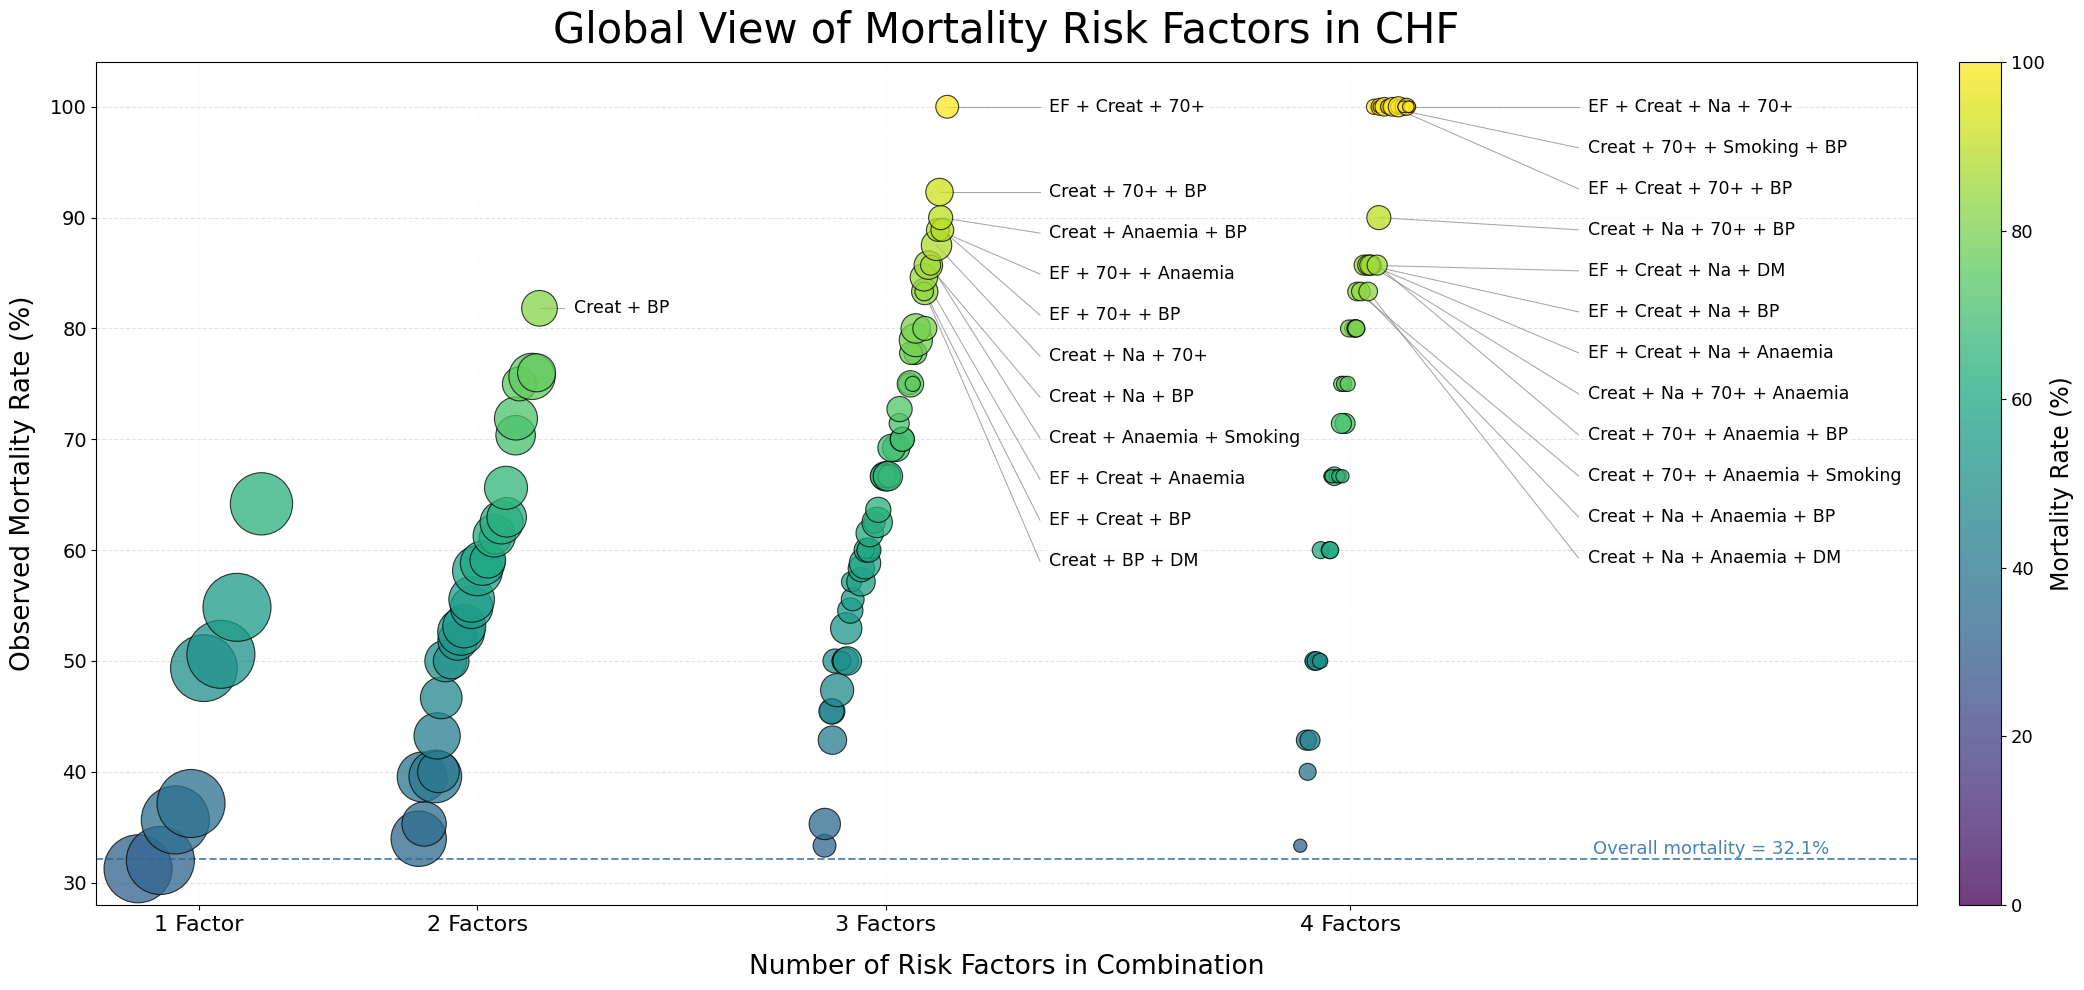


Combos labeled on chart (mortality > 80% and n >= 6):



,combo_label,n_factors,n_patients,deaths,mortality_rate
0,Creat + BP,2,22,18,81.8
1,EF + Creat + 70+,3,9,9,100.0
2,Creat + 70+ + BP,3,13,12,92.3
3,Creat + Anaemia + BP,3,10,9,90.0
4,EF + 70+ + Anaemia,3,9,8,88.9
5,EF + 70+ + BP,3,9,8,88.9
6,Creat + Na + 70+,3,16,14,87.5
7,Creat + Na + BP,3,14,12,85.7
8,Creat + Anaemia + Smoking,3,7,6,85.7
9,EF + Creat + Anaemia,3,13,11,84.6


In [ ]:
# =========================
# GLOBAL RISK LANDSCAPE
# Updated compact-label version for CHF mortality combinations
# =========================


import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# -------------------------
# 1. LOAD DATA
# -------------------------
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# -------------------------
# 2. CREATE BINARY RISK FEATURES
# -------------------------
df["low_ef"] = (df["ejection_fraction"] < 35).astype(int)
df["high_creatinine"] = (df["serum_creatinine"] > 1.5).astype(int)
df["low_sodium"] = (df["serum_sodium"] < 135).astype(int)
df["age_70_plus"] = (df["age"] >= 70).astype(int)

# Existing binary variables already in dataset:
# anaemia, diabetes, high_blood_pressure, smoking, sex

# -------------------------
# 3. SELECT FEATURES
# -------------------------
risk_features = [
    "low_ef",
    "high_creatinine",
    "low_sodium",
    "age_70_plus",
    "anaemia",
    "smoking",
    "high_blood_pressure",
    "diabetes"
]

outcome_col = "DEATH_EVENT"

# -------------------------
# 4. SHORT LABEL MAP
# -------------------------
pretty_name = {
    "low_ef": "EF",
    "high_creatinine": "Creat",
    "low_sodium": "Na",
    "age_70_plus": "70+",
    "anaemia": "Anaemia",
    "smoking": "Smoking",
    "high_blood_pressure": "BP",
    "diabetes": "DM"
}

# -------------------------
# 5. BUILD ALL 1- TO 4-WAY COMBINATIONS
# -------------------------
results = []

for r in range(1, 5):
    for combo in combinations(risk_features, r):
        mask = df[list(combo)].eq(1).all(axis=1)
        subset = df.loc[mask].copy()

        n_patients = len(subset)
        if n_patients == 0:
            continue

        deaths = int(subset[outcome_col].sum())
        mortality_rate = subset[outcome_col].mean() * 100
        combo_label = " + ".join(pretty_name[c] for c in combo)

        results.append({
            "combo": combo,
            "combo_label": combo_label,
            "n_factors": r,
            "n_patients": n_patients,
            "deaths": deaths,
            "mortality_rate": mortality_rate
        })

combo_df = pd.DataFrame(results)

# -------------------------
# 6. KEEP ALL BUBBLES
# -------------------------
plot_df = combo_df.copy()

# -------------------------
# 7. CUSTOM X POSITIONS WITH MORE SPACE BETWEEN GROUPS
# -------------------------
x_base_map = {
    1: 1.0,
    2: 2.5,
    3: 4.7,
    4: 7.2
}

np.random.seed(42)

def add_spread(group):
    group = group.sort_values("mortality_rate").copy()
    n = len(group)

    if n == 1:
        offsets = np.array([0.0])
    else:
        offsets = np.linspace(-0.32, 0.32, n)

    noise = np.random.uniform(-0.025, 0.025, n)
    group["x_plot"] = x_base_map[group["n_factors"].iloc[0]] + offsets + noise
    return group

plot_df = plot_df.groupby("n_factors", group_keys=False).apply(add_spread).reset_index(drop=True)

# -------------------------
# 8. BUBBLE SIZE
# -------------------------
# Slightly larger bubbles for better visibility
plot_df["bubble_size"] = plot_df["n_patients"] * 30
plot_df["bubble_size"] = plot_df["bubble_size"].clip(lower=70, upper=2400)

# -------------------------
# 9. LABEL ONLY HIGH-RISK COMBOS
# mortality > 80% and n >= 6
# -------------------------
label_df = plot_df[
    (plot_df["mortality_rate"] > 80) &
    (plot_df["n_patients"] >= 6)
].copy()

label_df = label_df.sort_values(
    by=["n_factors", "mortality_rate", "n_patients"],
    ascending=[True, False, False]
).reset_index(drop=True)

# Move labels closer to bubbles
label_x_map = {
    1: 1.48,
    2: 3.02,
    3: 5.58,
    4: 8.48
}

label_df["label_x"] = label_df["n_factors"].map(label_x_map)

# Tighter but non-overlapping vertical spacing
adjusted_rows = []
for factor, grp in label_df.groupby("n_factors"):
    grp = grp.sort_values("mortality_rate", ascending=False).copy()
    y_positions = grp["mortality_rate"].to_numpy().astype(float)

    min_gap = 3.7
    for i in range(1, len(y_positions)):
        if y_positions[i-1] - y_positions[i] < min_gap:
            y_positions[i] = y_positions[i-1] - min_gap

    grp["label_y"] = y_positions
    adjusted_rows.append(grp)

if len(adjusted_rows) > 0:
    label_df = pd.concat(adjusted_rows, ignore_index=True)

# -------------------------
# 10. PLOT
# -------------------------
fig, ax = plt.subplots(figsize=(21, 10))

scatter = ax.scatter(
    plot_df["x_plot"],
    plot_df["mortality_rate"],
    s=plot_df["bubble_size"],
    c=plot_df["mortality_rate"],
    cmap="viridis",
    alpha=0.76,
    edgecolors="black",
    linewidths=0.8,
    zorder=3
)

ax.set_xticks([x_base_map[i] for i in [1, 2, 3, 4]])
ax.set_xticklabels(["1 Factor", "2 Factors", "3 Factors", "4 Factors"], fontsize=16)

ax.set_xlabel("Number of Risk Factors in Combination", fontsize=19, labelpad=14)
ax.set_ylabel("Observed Mortality Rate (%)", fontsize=19, labelpad=10)
ax.set_title("Global View of Mortality Risk Factors in CHF", fontsize=30, pad=14)

# Wider frame, but keep labels closer to bubbles
ax.set_xlim(0.45, 10.25)
ax.set_ylim(28, 104)

ax.tick_params(axis='y', labelsize=14)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
ax.grid(axis="x", linestyle=":", alpha=0.12, zorder=0)

# Overall mortality line
overall_mortality = df[outcome_col].mean() * 100
ax.axhline(overall_mortality, linestyle="--", linewidth=1.4, color="steelblue", alpha=0.9)
ax.text(
    9.78,
    overall_mortality + 0.5,
    f"Overall mortality = {overall_mortality:.1f}%",
    fontsize=13,
    ha="right",
    color="steelblue"
)

# -------------------------
# 11. LABELS WITH SHORTER CONNECTOR LINES
# -------------------------
for _, row in label_df.iterrows():
    ax.plot(
        [row["x_plot"], row["label_x"] - 0.05],
        [row["mortality_rate"], row["label_y"]],
        color="gray",
        linewidth=0.75,
        alpha=0.7,
        zorder=2
    )

    ax.text(
        row["label_x"],
        row["label_y"],
        row["combo_label"],
        fontsize=12.5,
        ha="left",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor="none",
            alpha=0.78
        ),
        zorder=4
    )

# -------------------------
# 12. COLORBAR
# -------------------------
cbar = fig.colorbar(scatter, ax=ax, pad=0.022, fraction=0.032)
cbar.set_label("Mortality Rate (%)", fontsize=17)
cbar.ax.tick_params(labelsize=13)

plt.tight_layout()
plt.show()

# -------------------------
# 13. TABLE OF LABELED COMBOS
# -------------------------
labeled_table = label_df[[
    "combo_label", "n_factors", "n_patients", "deaths", "mortality_rate"
]].copy()

labeled_table = labeled_table.sort_values(
    by=["n_factors", "mortality_rate", "n_patients"],
    ascending=[True, False, False]
).reset_index(drop=True)

print("\nCombos labeled on chart (mortality > 80% and n >= 6):\n")
display(
    labeled_table.style.format({
        "mortality_rate": "{:.1f}"
    })
)

In [ ]:
def render_plotly_in_widget(fig):
    display(go.FigureWidget(fig))

In [ ]:
def build_progressive_chart(dataframe, selected_features, outcome_col="DEATH_EVENT"):
    if len(selected_features) == 0:
        return None

    rows = []
    current_features = []
    previous_mortality = 0

    for feat in selected_features:
        current_features.append(feat)
        _, n, deaths, mortality = summarize_group(dataframe, current_features, outcome_col)

        mortality = 0 if pd.isna(mortality) else mortality
        added_change = mortality - previous_mortality

        rows.append({
            "step_label": " + ".join(label_map[f] for f in current_features),
            "added_feature": label_map[feat],
            "n_patients": n,
            "mortality": mortality,
            "base_portion": previous_mortality,
            "added_portion": added_change
        })

        previous_mortality = mortality

    prog_df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(11, max(4.5, 0.9 * len(prog_df))))

    # Base cumulative portion
    ax.barh(
        prog_df["step_label"],
        prog_df["base_portion"],
        color="#cfe8ff",
        edgecolor="black",
        linewidth=0.8,
        label="Previous cumulative risk"
    )

    # Newly added change
    ax.barh(
        prog_df["step_label"],
        prog_df["added_portion"],
        left=prog_df["base_portion"],
        color="#d62728",
        edgecolor="black",
        linewidth=0.8,
        label="Change from added attribute"
    )

    ax.axvline(overall_mortality, linestyle="--", color="gray", linewidth=1.5)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Observed Mortality Rate (%)")
    ax.set_title("Progressive Analysis: Change in Mortality as Attributes Are Added")

    for i, row in prog_df.iterrows():
        ax.text(
            row["mortality"] + 1,
            i,
            f"{row['mortality']:.1f}% | +{row['added_feature']} | n={row['n_patients']}",
            va="center",
            fontsize=10
        )

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=1,
        fontsize=9,
        frameon=True
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# -------------------------
# LOAD DATA
# -------------------------
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# -------------------------
# CREATE BINARY RISK FEATURES
# -------------------------
df["low_ef"] = (df["ejection_fraction"] < 35).astype(int)
df["high_creatinine"] = (df["serum_creatinine"] > 1.5).astype(int)
df["low_sodium"] = (df["serum_sodium"] < 135).astype(int)
df["age_70_plus"] = (df["age"] >= 70).astype(int)
df["high_cpk"] = (df["creatinine_phosphokinase"] > 250).astype(int)
df["low_platelets"] = (df["platelets"] < 150000).astype(int)

# -------------------------
# LABELS AND FEATURE SETUP
# -------------------------
label_map = {
    "low_ef": "Low EF",
    "high_creatinine": "High Creatinine",
    "low_sodium": "Low Sodium",
    "age_70_plus": "Age ≥ 70",
    "high_cpk": "High CPK",
    "low_platelets": "Low Platelets",
    "anaemia": "Anaemia",
    "diabetes": "Diabetes",
    "high_blood_pressure": "High Blood Pressure",
    "sex": "Male",
    "smoking": "Smoking"
}

feature_order = [
    "low_ef",
    "high_creatinine",
    "low_sodium",
    "age_70_plus",
    "anaemia",
    "high_cpk",
    "low_platelets",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking"
]

high_risk_vars = ["low_ef", "high_creatinine", "low_sodium", "age_70_plus", "anaemia", "high_blood_pressure"]
default_features = ["low_ef", "high_creatinine", "low_sodium", "age_70_plus", "anaemia", "high_blood_pressure"]

outcome_col = "DEATH_EVENT"
overall_mortality = df[outcome_col].mean() * 100

# -------------------------
# HELPER FUNCTIONS
# -------------------------
def summarize_group(dataframe, features, outcome_col="DEATH_EVENT"):
    if len(features) == 0:
        subset = dataframe.copy()
    else:
        subset = dataframe[dataframe[features].eq(1).all(axis=1)].copy()

    n = len(subset)
    deaths = int(subset[outcome_col].sum()) if n > 0 else 0
    mortality = subset[outcome_col].mean() * 100 if n > 0 else np.nan
    return subset, n, deaths, mortality

def pretty_combo_text(features):
    if not features:
        return "All Patients"
    return " + ".join(label_map[f] for f in features)

def make_summary_html(selected_features, n, deaths, mortality):
    combo_text = pretty_combo_text(selected_features)
    mortality_text = f"{mortality:.1f}%" if pd.notna(mortality) else "N/A"
    mortality_color = "#c0392b" if pd.notna(mortality) and mortality >= overall_mortality else "#1f618d"

    high_risk_selected = [label_map[f] for f in selected_features if f in high_risk_vars]
    high_risk_note = ", ".join(high_risk_selected) if high_risk_selected else "None selected"

    return f"""
    <div style="
        background: linear-gradient(135deg, #f8fbff 0%, #eef4ff 100%);
        border: 1px solid #d6e4ff;
        border-radius: 18px;
        padding: 18px 22px;
        box-shadow: 0 4px 14px rgba(0,0,0,0.08);
        margin-bottom: 14px;
        font-family: Arial, sans-serif;
    ">
        <div style="font-size: 22px; font-weight: 700; color: #1f2d3d; margin-bottom: 10px;">
            CHF Mortality Risk Explorer
        </div>
        <div style="font-size: 14px; color: #4a4a4a; margin-bottom: 8px;">
            <b>Current combination:</b> {combo_text}
        </div>
        <div style="font-size: 13px; color: #6b7280; margin-bottom: 14px;">
            <b>Highlighted high-risk variables selected:</b> {high_risk_note}
        </div>
        <div style="display: flex; gap: 14px; flex-wrap: wrap;">
            <div style="
                background: white;
                border-radius: 14px;
                padding: 12px 18px;
                min-width: 150px;
                box-shadow: 0 2px 8px rgba(0,0,0,0.06);
            ">
                <div style="font-size: 12px; color: #6b7280;">Patients</div>
                <div style="font-size: 24px; font-weight: 700; color: #111827;">{n}</div>
            </div>
            <div style="
                background: white;
                border-radius: 14px;
                padding: 12px 18px;
                min-width: 150px;
                box-shadow: 0 2px 8px rgba(0,0,0,0.06);
            ">
                <div style="font-size: 12px; color: #6b7280;">Deaths</div>
                <div style="font-size: 24px; font-weight: 700; color: #111827;">{deaths}</div>
            </div>
            <div style="
                background: white;
                border-radius: 14px;
                padding: 12px 18px;
                min-width: 170px;
                box-shadow: 0 2px 8px rgba(0,0,0,0.06);
            ">
                <div style="font-size: 12px; color: #6b7280;">Observed Mortality</div>
                <div style="font-size: 24px; font-weight: 700; color: {mortality_color};">{mortality_text}</div>
            </div>
            <div style="
                background: white;
                border-radius: 14px;
                padding: 12px 18px;
                min-width: 190px;
                box-shadow: 0 2px 8px rgba(0,0,0,0.06);
            ">
                <div style="font-size: 12px; color: #6b7280;">Overall Dataset Mortality</div>
                <div style="font-size: 24px; font-weight: 700; color: #374151;">{overall_mortality:.1f}%</div>
            </div>
        </div>
    </div>
    """

def build_main_bar_matplotlib(mortality):
    value = 0 if pd.isna(mortality) else mortality

    fig, ax = plt.subplots(figsize=(8, 4.2))
    bars = ax.bar(["Current Group"], [value], edgecolor="black", linewidth=1)

    ax.axhline(overall_mortality, linestyle="--", color="gray", linewidth=1.5)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Mortality Rate (%)")
    ax.set_title("Observed Mortality for Current Combination")

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    ax.text(
        0.4,
        overall_mortality + 1,
        f"Overall mortality = {overall_mortality:.1f}%",
        fontsize=10,
        color="gray"
    )

    plt.tight_layout()
    return fig

def build_progressive_chart(dataframe, selected_features, outcome_col="DEATH_EVENT"):
    if len(selected_features) == 0:
        return None

    rows = []
    current_features = []
    previous_mortality = 0

    for feat in selected_features:
        current_features.append(feat)
        _, n, deaths, mortality = summarize_group(dataframe, current_features, outcome_col)

        mortality = 0 if pd.isna(mortality) else mortality
        added_change = mortality - previous_mortality

        rows.append({
            "step_label": " + ".join(label_map[f] for f in current_features),
            "added_feature": label_map[feat],
            "n_patients": n,
            "mortality": mortality,
            "base": previous_mortality,
            "added": added_change
        })

        previous_mortality = mortality

    prog_df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(11, max(4.5, 0.9 * len(prog_df))))

    # BLUE = previous cumulative
    ax.barh(
        prog_df["step_label"],
        prog_df["base"],
        color="#cfe8ff",
        edgecolor="black"
    )

    # RED = new added effect
    ax.barh(
        prog_df["step_label"],
        prog_df["added"],
        left=prog_df["base"],
        color="#d62728",
        edgecolor="black"
    )

    ax.axvline(overall_mortality, linestyle="--", color="gray", linewidth=1.5)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Observed Mortality Rate (%)")
    ax.set_title("Progressive Analysis: Change in Mortality as Attributes Are Added")

    for i, row in prog_df.iterrows():
        ax.text(
            row["mortality"] + 1,
            i,
            f"{row['mortality']:.1f}% | +{row['added_feature']} | n={row['n_patients']}",
            va="center",
            fontsize=10
        )

    ax.legend(
        ["Previous cumulative risk", "Change from added attribute"],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=1
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    return fig

# -------------------------
# CHECKBOX CONTROLS
# -------------------------
checkbox_inputs = {}
checkbox_rows = []

legend_html = widgets.HTML("""
<div style="font-family:Arial, sans-serif; font-size:13px; margin-bottom:10px; line-height:1.5;">
    <span style="color:#c0392b; font-weight:600;">● High-risk variables identified in earlier analysis</span><br>
    <span style="color:#374151;">● Other available variables for exploration</span>
</div>
""")

for feat in feature_order:
    cb = widgets.Checkbox(
        value=(feat in default_features),
        indent=False,
        layout=widgets.Layout(width="28px")
    )
    checkbox_inputs[feat] = cb

    if feat in high_risk_vars:
        label_html = f"<span style='color:#c0392b; font-weight:600; font-size:14px;'>{label_map[feat]}</span>"
    else:
        label_html = f"<span style='color:#374151; font-size:14px;'>{label_map[feat]}</span>"

    row = widgets.HBox(
        [cb, widgets.HTML(value=label_html)],
        layout=widgets.Layout(align_items="center", margin="2px 0")
    )
    checkbox_rows.append(row)

controls_box = widgets.VBox(
    [
        widgets.HTML("<b style='font-size:16px; font-family:Arial;'>Selected Risk Factors</b>"),
        legend_html
    ] + checkbox_rows,
    layout=widgets.Layout(
        width="290px",
        padding="16px",
        border="1px solid #d1d9e6",
        border_radius="16px",
        background_color="white"
    )
)

title_html = widgets.HTML("""
<div style="
    background: linear-gradient(135deg, #243b55 0%, #141e30 100%);
    color: white;
    padding: 16px 20px;
    border-radius: 18px;
    font-family: Arial, sans-serif;
    box-shadow: 0 4px 14px rgba(0,0,0,0.12);
    margin-bottom: 10px;
">
    <div style="font-size: 24px; font-weight: 700;">CHF Mortality Risk Explorer</div>
    <div style="font-size: 14px; margin-top: 6px; opacity: 0.92;">
        Start with a full risk profile, then remove variables to see which factors are truly driving mortality risk.
    </div>
</div>
""")

instruction_html = widgets.HTML("""
<div style="
    font-family: Arial, sans-serif;
    font-size: 14px;
    color: #374151;
    padding: 4px 2px 12px 2px;
">
    <b>How to use:</b> Uncheck a variable to remove it from the current risk combination.
</div>
""")

output = widgets.Output()

# -------------------------
# DASHBOARD UPDATE
# -------------------------
def update_dashboard(*args):
    selected_features = [feat for feat in feature_order if checkbox_inputs[feat].value]

    with output:
        plt.close('all')
        clear_output(wait=True)

        _, n, deaths, mortality = summarize_group(df, selected_features, outcome_col)

        display(HTML(make_summary_html(selected_features, n, deaths, mortality)))

        if n == 0:
            display(HTML("""
            <div style="
                background:#fff4f4;
                color:#8a1c1c;
                border:1px solid #f3c2c2;
                padding:16px;
                border-radius:14px;
                font-family:Arial,sans-serif;
                font-size:14px;
            ">
                No patients match the currently selected combination. Try removing one or more variables.
            </div>
            """))
            return

        fig_prog = build_progressive_chart(df, selected_features, outcome_col)
        if fig_prog is not None:
            display(fig_prog)
            plt.close(fig_prog)


for cb in checkbox_inputs.values():
    cb.observe(update_dashboard, names="value")

# -------------------------
# HIGH-RISK COMBO SELECTOR
# -------------------------
high_risk_combo_df = combo_df[
    (combo_df["mortality_rate"] > 80) &
    (combo_df["n_patients"] >= 6)
].copy()

high_risk_combo_df = high_risk_combo_df.sort_values(
    by=["n_factors", "mortality_rate", "n_patients"],
    ascending=[True, False, False]
).reset_index(drop=True)

combo_lookup = {}
combo_options = []

for _, row in high_risk_combo_df.iterrows():
    display_text = f"{row['combo_label']} ({row['mortality_rate']:.1f}%)"
    combo_options.append(display_text)
    combo_lookup[display_text] = list(row["combo"])

combo_selector_title = widgets.HTML("""
<div style="font-family:Arial,sans-serif;font-size:16px;font-weight:700;margin-bottom:10px;">
Select High-Risk Combination
</div>
""")

combo_selector_help = widgets.HTML("""
<div style="font-family:Arial,sans-serif;font-size:13px;color:#4b5563;margin-bottom:10px;line-height:1.4;">
Choose a high-risk group, then click the button to load it into the tool.
</div>
""")

combo_selector_widget = widgets.Select(
    options=combo_options,
    rows=min(14, len(combo_options)),
    layout=widgets.Layout(width="340px", height="255px")
)

load_combo_button = widgets.Button(
    description="Load Selected Combo",
    button_style="primary",
    layout=widgets.Layout(width="190px", height="36px")
)

combo_status = widgets.HTML("""
<div style="font-family:Arial,sans-serif;font-size:12px;color:#6b7280;margin-top:8px;">
Ready
</div>
""")

_is_loading_combo = False

def load_selected_combo(_):
    global _is_loading_combo

    selected_label = combo_selector_widget.value
    if selected_label is None:
        combo_status.value = """
        <div style="font-family:Arial,sans-serif;font-size:12px;color:#b91c1c;margin-top:8px;">
        No combination selected.
        </div>
        """
        return

    selected_combo = combo_lookup[selected_label]

    _is_loading_combo = True
    try:
        for feat in checkbox_inputs:
            checkbox_inputs[feat].value = False

        for feat in selected_combo:
            checkbox_inputs[feat].value = True
    finally:
        _is_loading_combo = False

    update_dashboard()

    combo_status.value = f"""
    <div style="font-family:Arial,sans-serif;font-size:12px;color:#065f46;margin-top:8px;">
    Loaded: {selected_label}
    </div>
    """

load_combo_button.on_click(load_selected_combo)

combo_selector_box = widgets.VBox(
    [
        combo_selector_title,
        combo_selector_help,
        combo_selector_widget,
        widgets.Box([load_combo_button], layout=widgets.Layout(margin="10px 0 0 0")),
        combo_status
    ],
    layout=widgets.Layout(
        width="370px",
        padding="16px",
        border="1px solid #d1d9e6",
        border_radius="16px",
        background_color="white"
    )
)

for feat, cb in checkbox_inputs.items():
    try:
        cb.unobserve_all()
    except Exception:
        pass

    def _make_observer():
        def _observer(change):
            if change["name"] == "value" and not _is_loading_combo:
                update_dashboard()
        return _observer

    cb.observe(_make_observer(), names="value")



In [ ]:
# HIGH-RISK COMBO SELECTOR
# integrated with dashboard
# =========================

import ipywidgets as widgets
from IPython.display import display, clear_output

# Build high-risk combo list from combo_df
high_risk_combo_df = combo_df[
    (combo_df["mortality_rate"] > 80) &
    (combo_df["n_patients"] >= 6)
].copy()

high_risk_combo_df = high_risk_combo_df.sort_values(
    by=["n_factors", "mortality_rate", "n_patients"],
    ascending=[True, False, False]
).reset_index(drop=True)

combo_lookup = {}
combo_options = []

for _, row in high_risk_combo_df.iterrows():
    display_text = f"{row['combo_label']} ({row['mortality_rate']:.1f}%)"
    combo_options.append(display_text)
    combo_lookup[display_text] = list(row["combo"])

combo_selector_title = widgets.HTML("""
<div style="font-family:Arial,sans-serif;font-size:16px;font-weight:700;margin-bottom:10px;">
Select High-Risk Combination
</div>
""")

combo_selector_help = widgets.HTML("""
<div style="font-family:Arial,sans-serif;font-size:13px;color:#4b5563;margin-bottom:10px;line-height:1.4;">
Choose a high-risk group, then click the button to load it into the tool.
</div>
""")

combo_selector_widget = widgets.Select(
    options=combo_options,
    rows=min(14, len(combo_options)),
    layout=widgets.Layout(width="340px", height="255px")
)

load_combo_button = widgets.Button(
    description="Load Selected Combo",
    button_style="primary",
    layout=widgets.Layout(width="190px", height="36px")
)

combo_status = widgets.HTML("""
<div style="font-family:Arial,sans-serif;font-size:12px;color:#6b7280;margin-top:8px;">
Ready
</div>
""")

# Prevent multiple refreshes while boxes are being set
_is_loading_combo = False

def load_selected_combo(_):
    global _is_loading_combo

    selected_label = combo_selector_widget.value
    if selected_label is None:
        combo_status.value = """
        <div style="font-family:Arial,sans-serif;font-size:12px;color:#b91c1c;margin-top:8px;">
        No combination selected.
        </div>
        """
        return

    selected_combo = combo_lookup[selected_label]

    _is_loading_combo = True
    try:
        # Clear all first
        for feat in checkbox_inputs:
            checkbox_inputs[feat].value = False

        # Apply selected combo
        for feat in selected_combo:
            checkbox_inputs[feat].value = True
    finally:
        _is_loading_combo = False

    # Single refresh after all boxes are updated

    update_dashboard()

    combo_status.value = f"""
    <div style="font-family:Arial,sans-serif;font-size:12px;color:#065f46;margin-top:8px;">
    Loaded: {selected_label}
    </div>
    """

load_combo_button.on_click(load_selected_combo)

combo_selector_box = widgets.VBox(
    [
        combo_selector_title,
        combo_selector_help,
        combo_selector_widget,
        widgets.Box([load_combo_button], layout=widgets.Layout(margin="10px 0 0 0")),
        combo_status
    ],
    layout=widgets.Layout(
        width="370px",
        padding="16px",
        border="1px solid #d1d9e6",
        border_radius="16px",
        background_color="white"
    )
)

# Optional: if your checkbox observers call update_dashboard directly,
# redefine them to ignore updates during combo loading.
# Only run this part if checkbox_inputs already exists.
for feat, cb in checkbox_inputs.items():
    try:
        cb.unobserve_all()
    except Exception:
        pass

    def _make_observer():
        def _observer(change):
            if change["name"] == "value" and not _is_loading_combo:
                update_dashboard()
        return _observer

    cb.observe(_make_observer(), names="value")



In [ ]:
dashboard = widgets.VBox([
    title_html,
    instruction_html,
    widgets.HBox(
        [controls_box, combo_selector_box, output],
        layout=widgets.Layout(align_items="flex-start", gap="18px")
    )
])

clear_output(wait=True)
display(dashboard)
update_dashboard()

In [6]:
import os

for name in os.listdir("/content"):
    print(repr(name))

'.config'
'sample_data'


In [4]:
import json

input_file = "/content/CHF_Mortality_Risk_Tool.ipynb"
output_file = "/content/CHF_Mortality_Risk_Tool_clean.ipynb"

with open(input_file, "r", encoding="utf-8") as f:
    notebook = json.load(f)

notebook.get("metadata", {}).pop("widgets", None)

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(notebook, f, indent=1)

print(f"Clean notebook saved to: {output_file}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/CHF_Mortality_Risk_Tool.ipynb'